## Softmax Regression / Multinomial Logistic Regression

It is used for **multi-class classification**, where binary logistic regression is not sufficient.

Logistic regression can be seen as a **special case of softmax regression (K = 2)**.

---

## Softmax Function

For K classes, we compute probability of class i as:

$$
P(y = i \mid \mathbf{z}) =
\frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}
$$

---

## Intuition

- Each class gets a score \(z_i\)
- Exponentiation converts scores into positive values
- Division normalizes them so that:

$$
\sum_{i=1}^{K} P(y=i) = 1
$$

---

## Key Idea

Softmax converts raw model outputs (logits) into probabilities over multiple classes.

---

## Output Behavior

- Highest \(z_i\) → highest probability
- All probabilities lie between 0 and 1
- Sum of all probabilities = 1

---

## Logistic vs Softmax

- Logistic Regression → 2 classes  
- Softmax Regression → K classes  
- Logistic = special case of Softmax (K = 2)

## Training

Suppose we have **3 classes**.

### Step 1: One-Hot Encoding

We convert output into one-hot encoded form:

Class A → (1, 0, 0)  
Class B → (0, 1, 0)  
Class C → (0, 0, 1)

This converts the problem into **3 binary classification problems**.

---

### Step 2: Dataset Split

We split the dataset into 3 parts:

- D₁ → targets class 0  
- D₂ → targets class 1  
- D₃ → targets class 2  

Each dataset behaves like a **binary logistic regression problem**.

---

### Step 3: Train Logistic Models

We train 3 logistic regression models:

For class (0):
$$
z^{(0)} = w_1^{(0)} x_1 + w_2^{(0)} x_2 + w_3^{(0)} x_3
$$

For class (1):
$$
z^{(1)} = w_1^{(1)} x_1 + w_2^{(1)} x_2 + w_3^{(1)} x_3
$$

For class (2):
$$
z^{(2)} = w_1^{(2)} x_1 + w_2^{(2)} x_2 + w_3^{(2)} x_3
$$

So total parameters learned:

- \(w_1^{(0)}, w_2^{(0)}, w_3^{(0)}\)  
- \(w_1^{(1)}, w_2^{(1)}, w_3^{(1)}\)  
- \(w_1^{(2)}, w_2^{(2)}, w_3^{(2)}\)

---

## Prediction

We compute scores from each model:

$$
z_0 = w_0^{(0)} + \sum_{j} w_j^{(0)} x_j
$$

$$
z_1 = w_0^{(1)} + \sum_{j} w_j^{(1)} x_j
$$

$$
z_2 = w_0^{(2)} + \sum_{j} w_j^{(2)} x_j
$$

---

## Softmax

We convert these scores into probabilities:

$$
P(y=i \mid x) =
\frac{e^{z_i}}{e^{z_0} + e^{z_1} + e^{z_2}}
$$

---

## Final Prediction

$$
\hat{y} = \arg\max (P(y=0), P(y=1), P(y=2))
$$

The class with highest probability is selected as output.

## Better Approach for Multi-Class Classification

The previous approach (training multiple logistic regression models) is not efficient when the number of classes becomes large.

So instead of training separate models, we modify the **loss function**.

---

## Binary Cross Entropy (Original)

For logistic regression:

$$
L = -\frac{1}{m} \sum_{i=1}^{m}
\left[
y_i \log(\hat{y}_i) + (1 - y_i)\log(1 - \hat{y}_i)
\right]
$$

---

## Multiclass Cross Entropy (Final)

For K classes:

$$
L = -\frac{1}{m} \sum_{i=1}^{m} \sum_{k=1}^{K}
y_k^{(i)} \log(\hat{y}_k^{(i)})
$$

---

## Intuition

- \(y_k^{(i)}\) is one-hot encoded (only correct class = 1, others = 0)
- So only the correct class contributes to loss
- Model is penalized when it assigns low probability to correct class

---

## Key Idea

Instead of building K models:

- we build **one model**
- output is a probability distribution (softmax)
- loss directly optimizes all classes together

---

## Benefit

- scalable to large number of classes  
- more stable training  
- used in modern neural networks and classifiers

In [3]:
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = sns.load_dataset('iris')

In [5]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [6]:
encoder = LabelEncoder()
df['species'] = encoder.fit_transform(df['species'])

In [7]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [8]:
df = df[['sepal_length','petal_length','species']]

In [9]:
df.head()

,sepal_length,petal_length,species
0,5.1,1.4,0
1,4.9,1.4,0
2,4.7,1.3,0
3,4.6,1.5,0
4,5.0,1.4,0


In [10]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [11]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [13]:
clf = LogisticRegression()
clf.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [14]:
y_pred = clf.predict(X_test)

In [15]:
print(accuracy_score(y_test,y_pred))

0.9666666666666667


In [16]:
pd.DataFrame(confusion_matrix(y_test,y_pred))

,0,1,2
0,14,0,0
1,0,7,1
2,0,0,8


In [17]:
query = np.array([[3.4,2.7]])
clf.predict_proba(query)

c:\Users\LENOVO\Desktop\Fusemachines AI Fellowship 2026\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([[7.25865651e-01, 2.73720718e-01, 4.13631316e-04]])

In [18]:
clf.predict(query)

c:\Users\LENOVO\Desktop\Fusemachines AI Fellowship 2026\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([0])

c:\Users\LENOVO\Desktop\Fusemachines AI Fellowship 2026\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


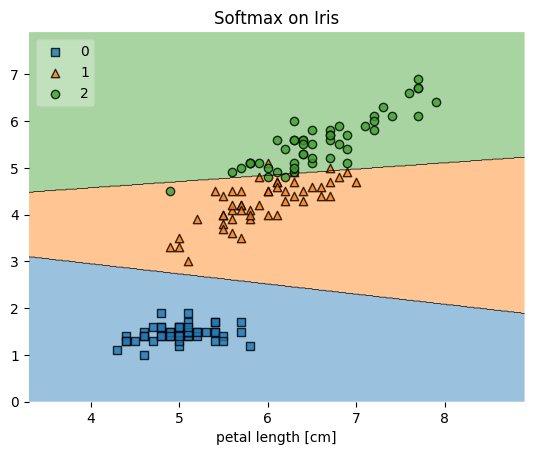

In [20]:
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(X.values, y.values, clf, legend=2)

# Adding axes annotations
plt.xlabel('sepal length [cm]')
plt.xlabel('petal length [cm]')
plt.title('Softmax on Iris')

plt.show()